<a href="https://colab.research.google.com/github/Burkifa23/kwizeramugwaneza_frank_lab0/blob/master/lab0_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 5: Pandas Data Analysis (30 points)

Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.

In [5]:
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math',
         'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan



In [6]:
# Task 1: Data Cleaning and Exploration (10 points)
# Done: Display basic information about the dataset
df.info()
# Done: Identify and count missing values
df.isnull().sum()
# Done: Fill missing exam_score with the mean score for the student's major
df['exam_score']=df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'))

# Done: Fill missing hours_studied with the median for the student's year
df['hours_studied']=df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'))

df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int32  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(2), int64(1), object(1)
memory usage: 7.9+ KB


,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,14.031175
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370
...,...,...,...,...,...,...
195,1195,Math,4,60.925362,2,14.213931
196,1196,Math,4,67.815558,10,20.402299
197,1197,Biology,2,72.865528,1,5.775474
198,1198,CS,4,78.109076,9,9.914039


In [7]:
# Task 2: Analysis (10 points)
# Done: Calculate and display the average exam_score by major
avg_exam_score=df.groupby('major')['exam_score'].agg('mean')

# Done: Find the major with the highest average exam_score
highest_avg_exam_score=avg_exam_score.idxmax()


# Done: Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])


# Done: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df['performance'] = pd.cut(df['exam_score'], bins=[0,70,80,90,100], labels=['Needs Improvement', 'Average', 'Good', 'Excellent'])

df.head()


,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
0,1000,Physics,3,68.199753,10,14.031175,Needs Improvement
1,1001,Biology,4,77.322537,9,12.204873,Average
2,1002,CS,3,77.930725,9,7.829556,Average
3,1003,Physics,1,67.856486,2,14.042336,Needs Improvement
4,1004,Physics,4,93.657745,6,15.287370,Excellent


In [8]:
# Task 3: Advanced Analysis (10 points)
# DONE: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
df.groupby(['major', 'year']).agg({'student_id':'count', 'exam_score':'mean', 'hours_studied':'mean'})

# DONE: Identify top 5 students based on exam_score (handle ties appropriately)
df.nlargest(5, 'exam_score')

# DONE: Create a pivot table showing average exam_score by major (rows) and year (columns)
df.pivot_table(values='exam_score',index='major',columns='year',aggfunc='mean')

year,1,2,3,4
major,,,,
Biology,76.570059,74.899613,80.178476,70.697689
CS,77.098194,76.155936,72.347626,78.119997
Math,74.053167,81.226714,72.017537,73.103066
Physics,77.828686,73.277734,73.134319,78.130194


### Exercise 6: Data Visualization (25 points)
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

Text(0.5, 1.0, 'Box plot of exam scores by major')

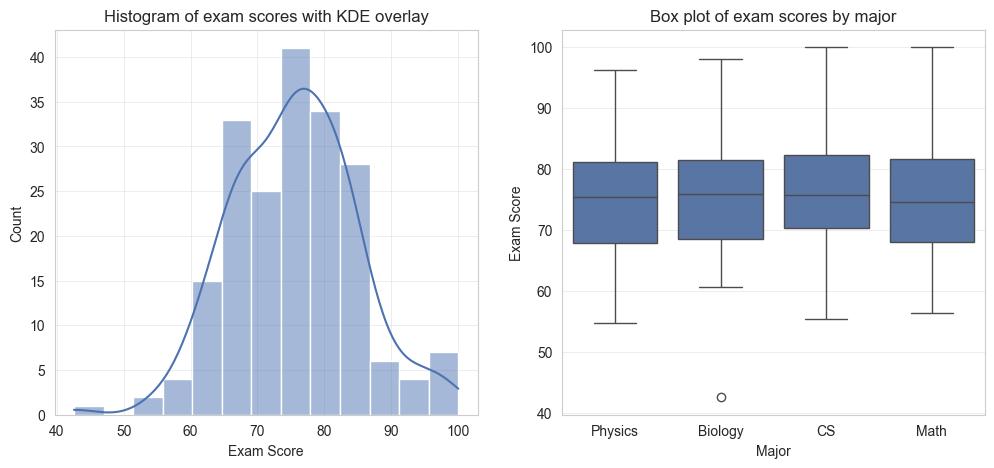

In [16]:

# Task 1: Distribution Visualization (8 points)
# Done: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# Done: Add appropriate titles, labels, and styling



fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

# Set style
sns.set_style("whitegrid")
sns.set_palette("deep")

# Histogram
sns.histplot(data=df['exam_score'], ax=ax1, kde=True)
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Count')
ax1.set_title('Histogram of exam scores with KDE overlay')


# Box plot
sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')
ax2.set_title('Box plot of exam scores by major')



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Hours Studied vs Exam Score')

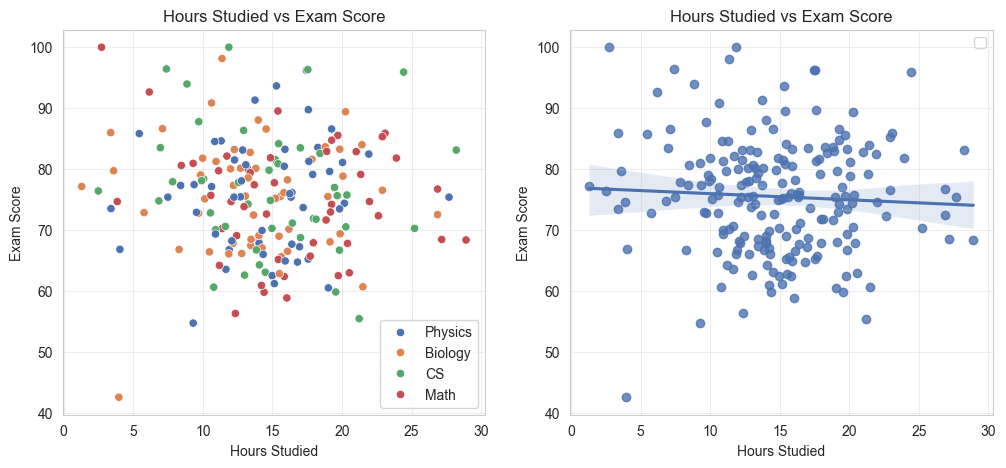

In [20]:
# Task 2: Relationship Visualization (8 points)
# Done: Create a scatter plot of hours_studied vs exam_score
# Done: Color points by major
# Done: Add a regression line
# Done: Include appropriate legends, titles, and axis labels

fig, (bx1,bx2) = plt.subplots(1,2,figsize=(12,5))

# Set style
sns.set_style("whitegrid")
sns.set_palette("deep")


# Scatter plot with regression line
sns.scatterplot(data=df, x='hours_studied', y='exam_score', ax=bx1, hue='major')
bx1.legend()
bx1.set_xlabel('Hours Studied')
bx1.set_ylabel('Exam Score')
bx1.set_title('Hours Studied vs Exam Score')

scattered_regressed=sns.regplot(data=df, x='hours_studied', y='exam_score', ax=bx2)
bx2.legend()
bx2.set_xlabel('Hours Studied')
bx2.set_ylabel('Exam Score')
bx2.set_title('Hours Studied vs Exam Score')


In [ ]:
# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability

### Exercise 7: Integration Challenge (25 points)

Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.



In [ ]:
# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


In [ ]:
# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)



In [ ]:
# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70



In [ ]:
# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV



In [ ]:
# TODO: Identify top 10% of customers by CLV



In [ ]:
# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap



In [ ]:
# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations